In [25]:
#IMPORTING LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
#LOADING DATASET
file_path = r"../data/Bosch_Demand_Datasheet.xlsx"
df = pd.read_excel(file_path, sheet_name = "Premium Plus Black")
df.head(20)


,Year,Demand: Black
0,2008-01-01,95
1,2008-02-01,94
2,2008-03-01,98
3,2008-04-01,96
4,2008-05-01,95
5,2008-06-01,115
6,2008-07-01,107
7,2008-08-01,104
8,2008-09-01,96
9,2008-10-01,112


In [27]:
#FORMATTING DATASET
df = df.rename(
    columns={
        "Year" : "Date",
        "Demand: Black" : "Demand",
    }
)

df["Date"] = pd.to_datetime(df["Date"])
#df["Demand"].describe()

df["Month"] = df["Date"].dt.month

df.groupby("Month")["Demand"].mean()

Month
1     115.222222
2     120.000000
3     122.111111
4     119.333333
5     118.666667
6     154.333333
7     142.888889
8     131.222222
9     121.444444
10    129.777778
11    132.666667
12    144.111111
Name: Demand, dtype: float64

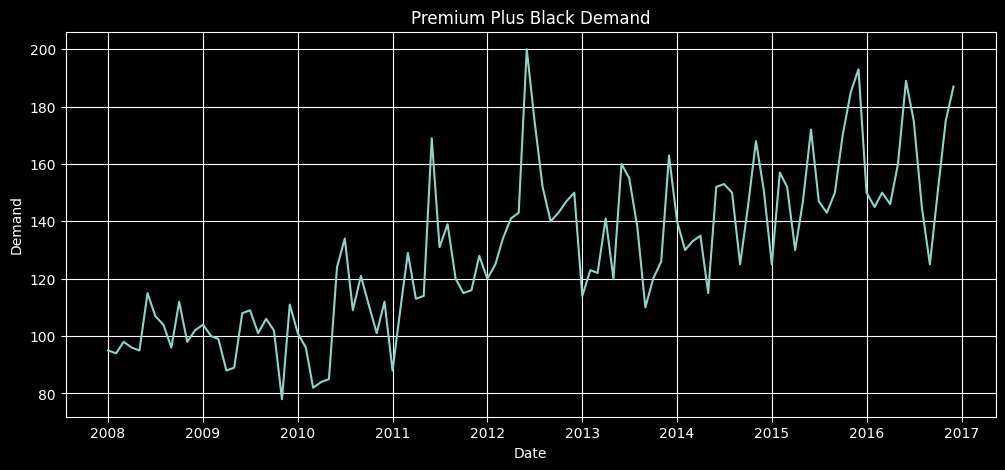

In [42]:
#PLOTTING ACTUAL DEMAND
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"])
plt.title("Premium Plus Black Demand")
plt.xlabel("Date")
plt.ylabel("Demand")
plt.grid(True)
plt.show()

In [29]:
#TESTING SES HYPOTHESIS
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
ses_model = SimpleExpSmoothing(df["Demand"]).fit(optimized=True)
print("Alpha: ",ses_model.params["smoothing_level"])

Alpha:  0.25439730024360185


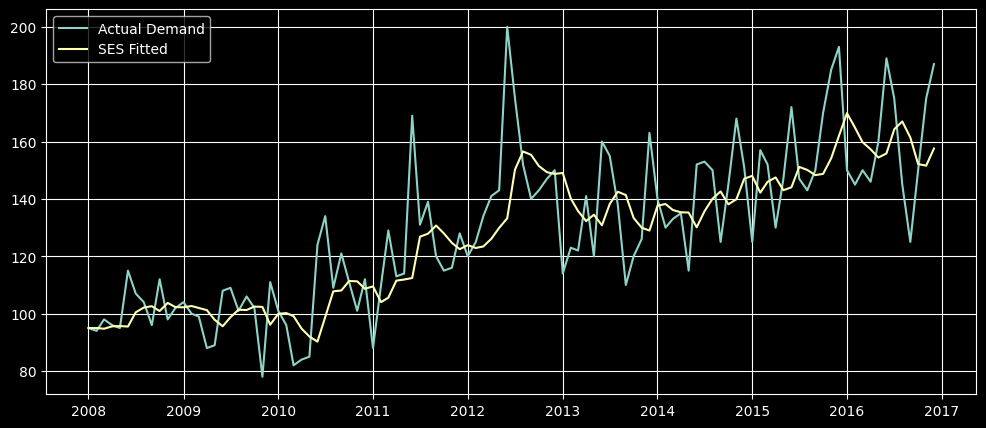

In [30]:
#PLOTTING ACTUAL VS SES FITTED DEMAND
df["SES_fitted"] = ses_model.fittedvalues

plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"],label="Actual Demand")
plt.plot(df["Date"], df["SES_fitted"],label="SES Fitted")
plt.legend()
plt.grid(True)
plt.show()

In [31]:
#SES ERROR CALCULATION
df["Error"] = df["Demand"] - df["SES_fitted"]
df["Abs_Error"] = abs(df["Error"])
SES_mae = df["Abs_Error"].mean()

df["Abs_Pct_Error"] = (df["Abs_Error"] / df["Demand"])*100
SES_mape = df["Abs_Pct_Error"].mean()

print("SES MAE: ", SES_mae)
print("SES MAPE: ", SES_mape,"%")

SES MAE:  12.953132505018432
SES MAPE:  9.662263975690491 %


In [32]:
#TESTING HOLT'S HYPOTHESIS
from statsmodels.tsa.holtwinters import Holt
holt_model = Holt(df["Demand"]).fit(optimized=True)
print(holt_model.params)

{'smoothing_level': np.float64(0.2569928577758267), 'smoothing_trend': np.float64(0.028147720078575585), 'smoothing_seasonal': np.float64(nan), 'damping_trend': nan, 'initial_level': np.float64(95.0), 'initial_trend': np.float64(-1.0), 'initial_seasons': array([], dtype=float64), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


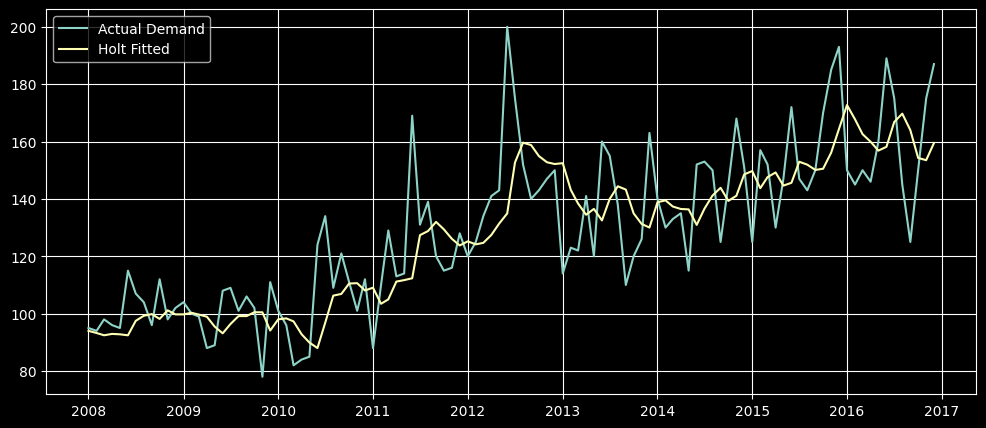

In [33]:
#PLOTTING ACTUAL VS HOLT'S FITTED DEMAND
df["Holt_Fitted"] = holt_model.fittedvalues
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"], label="Actual Demand")
plt.plot(df["Date"], df["Holt_Fitted"], label="Holt Fitted")
plt.legend()
plt.grid(True)
plt.show()

In [34]:
#HOLT'S ERROR CALCULATION
df["Holt_Error"] = df["Demand"] - df["Holt_Fitted"]
df["Holt_Abs_Error"] = abs(df["Holt_Error"])

holt_mae = df["Holt_Abs_Error"].mean()
print("MAE for Holt: ", holt_mae)
df["Holt_Abs_Pct_Error"] = (df["Holt_Abs_Error"]/df["Demand"])*100
holt_mape = df["Holt_Abs_Pct_Error"].mean()
print("MAPE for Holt: ", holt_mape,"%")

MAE for Holt:  13.299652487562868
MAPE for Holt:  9.975956185975914 %


In [35]:
#TESTING HOLT-WINTERS(HW) ADDITIVE HYPOTHESIS
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw_model = ExponentialSmoothing(
    df["Demand"],
    trend="add",
    seasonal="add",
    seasonal_periods=12
    ).fit(optimized=True)
print(hw_model.params)

{'smoothing_level': np.float64(0.5442317240035784), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(102.61693692202176), 'initial_trend': np.float64(0.6241068324356533), 'initial_seasons': array([-10.61843424,  -6.47151693,  -4.98440471,  -8.38619095,
        -9.67334178,  25.36959198,  13.30398928,   1.01094068,
        -9.38992832,  -1.67591764,   0.59138478,  11.41193308]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


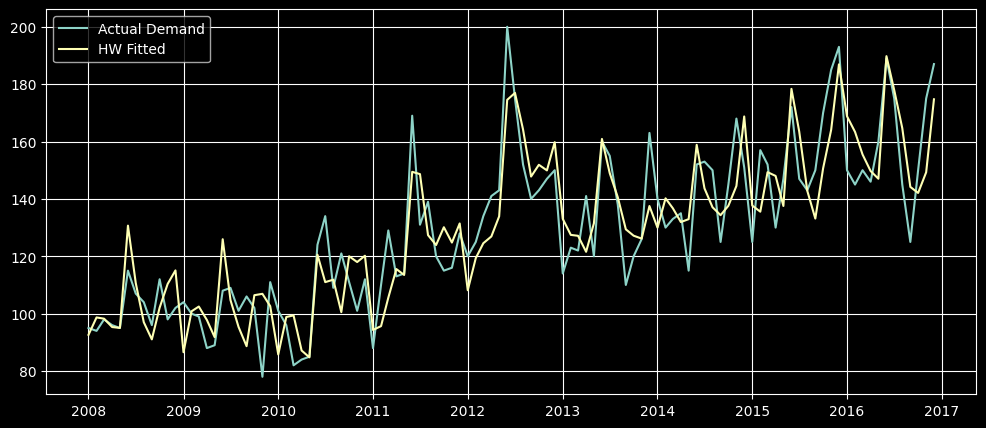

In [36]:
#PLOTTING ACTUAL VS HOLT-WINTERS(HW) ADDITIVE FITTED VALUES
df["HW_Fitted"] = hw_model.fittedvalues
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"], label="Actual Demand")
plt.plot(df["Date"], df["HW_Fitted"], label="HW Fitted")
plt.legend()
plt.grid(True)
plt.show()

In [37]:
#HW ADDITIVE ERROR CALCULATION
df["HW_Error"] = df["Demand"] - df["HW_Fitted"]

df["HW_Abs_Error"] = abs(df["HW_Error"])
df["HW_Abs_Pct_Error"] = (df["HW_Abs_Error"] / df["Demand"]) * 100

print("HW MAE :", df["HW_Abs_Error"].mean())
print("HW MAPE:", df["HW_Abs_Pct_Error"].mean(), "%")

HW MAE : 10.339660028758507
HW MAPE: 8.115369213258756 %


{'smoothing_level': np.float64(0.5625904077703185), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(102.12715067251806), 'initial_trend': np.float64(1.0034209448053544), 'initial_seasons': array([0.90883062, 0.94165674, 0.95687366, 0.93198678, 0.92687082,
       1.19633485, 1.09603477, 1.00034025, 0.91732029, 0.98105555,
       1.0164597 , 1.08824646]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


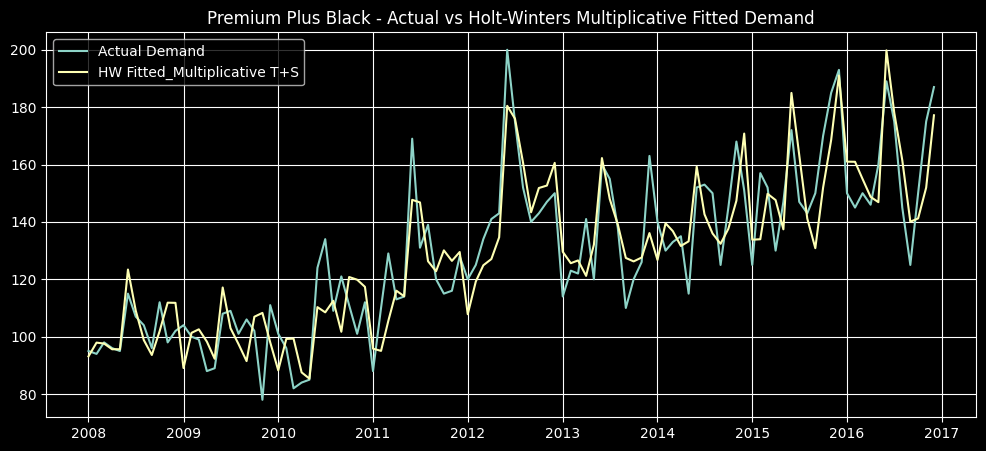

Multiplicative HW MAE : 9.98324351692399
Multiplicative HW MAPE: 7.825761959319018 %


In [43]:
#TESTING HW MULTIPLICATIVE HYPOTHESIS
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw_model_tsmul = ExponentialSmoothing(
    df["Demand"],
    trend="mul",
    seasonal="mul",
    seasonal_periods=12
    ).fit(optimized=True)
print(hw_model_tsmul.params)

#PLOTTING ACTUAL VS HW MULTIPLICATIVE FITTED DEMAND
df["HW_Fitted_tsmul"] = hw_model_tsmul.fittedvalues
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"], label="Actual Demand")
plt.plot(df["Date"], df["HW_Fitted_tsmul"], label="HW Fitted_Multiplicative T+S")
plt.title("Premium Plus Black - Actual vs Holt-Winters Multiplicative Fitted Demand")
plt.legend()
plt.grid(True)
plt.show()

#HW MULTIPLICATIVE ERROR CALCULATION
df["HW_Fitted_tsmul"] = hw_model_tsmul.fittedvalues

df["HW_Mul_Error"] = df["Demand"] - df["HW_Fitted_tsmul"]
df["HW_Mul_Abs_Error"] = abs(df["HW_Mul_Error"])

hw_mul_mae = df["HW_Mul_Abs_Error"].mean()

df["HW_Mul_Abs_Pct_Error"] = (df["HW_Mul_Abs_Error"] / df["Demand"]) * 100

hw_mul_mape = df["HW_Mul_Abs_Pct_Error"].mean()

print("Multiplicative HW MAE :", hw_mul_mae)
print("Multiplicative HW MAPE:", hw_mul_mape,"%")

{'smoothing_level': np.float64(0.5618362882061854), 'smoothing_trend': np.float64(0.0), 'smoothing_seasonal': np.float64(0.0), 'damping_trend': nan, 'initial_level': np.float64(102.12321360104849), 'initial_trend': np.float64(0.617007877014207), 'initial_seasons': array([0.90464753, 0.9372595 , 0.95232314, 0.92766536, 0.92265157,
       1.18999244, 1.09014485, 0.99503085, 0.91272293, 0.97589478,
       1.01083707, 1.08213378]), 'use_boxcox': False, 'lamda': None, 'remove_bias': False}


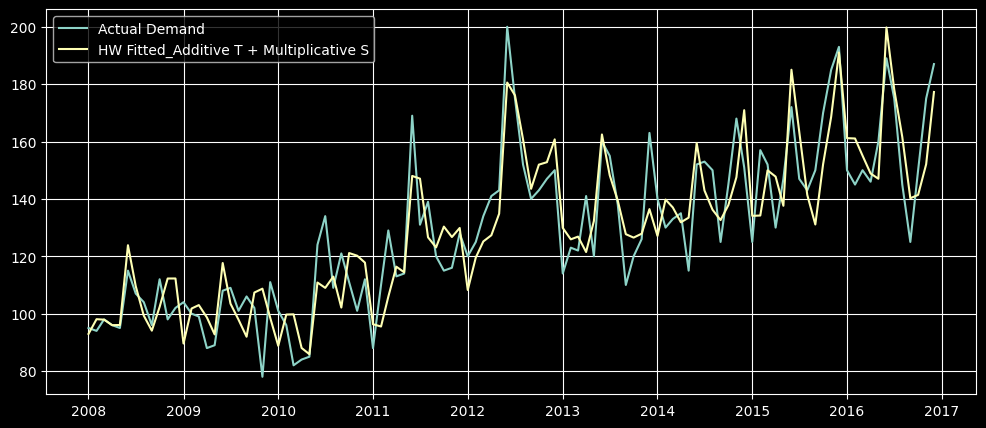

Multiplicative S HW MAE : 10.017709826796052
Multiplicative S HW MAPE: 7.825761959319018 %


In [39]:
#TESTING HW ADDITIVE TREND + MULTIPLICATIVE SEASONALITY HYPOTHESIS
from statsmodels.tsa.holtwinters import ExponentialSmoothing
hw_model_smul = ExponentialSmoothing(
    df["Demand"],
    trend="add",
    seasonal="mul",
    seasonal_periods=12
    ).fit(optimized=True)
print(hw_model_smul.params)

#PLOTTING ACTUAL VS FITTED DEMAND
df["HW_Fitted_smul"] = hw_model_smul.fittedvalues
plt.figure(figsize=(12,5))
plt.plot(df["Date"], df["Demand"], label="Actual Demand")
plt.plot(df["Date"], df["HW_Fitted_smul"], label="HW Fitted_Additive T + Multiplicative S")
plt.legend()
plt.grid(True)
plt.show()

#ERROR CALCULATION
df["HW_Fitted_smul"] = hw_model_smul.fittedvalues

df["HW_S_Mul_Error"] = df["Demand"] - df["HW_Fitted_smul"]
df["HW_S_Mul_Abs_Error"] = abs(df["HW_S_Mul_Error"])

hw_smul_mae = df["HW_S_Mul_Abs_Error"].mean()

df["HW_S_Mul_Abs_Pct_Error"] = (df["HW_S_Mul_Abs_Error"] / df["Demand"]) * 100

hw_smul_mape = df["HW_Mul_Abs_Pct_Error"].mean()

print("Multiplicative S HW MAE :", hw_smul_mae)
print("Multiplicative S HW MAPE:", hw_smul_mape,"%")

      Minimum  Maximum  Range
Date                         
2008       94      115     21
2009       78      111     33
2010       82      134     52
2011       88      169     81
2012      120      200     80
2013      110      163     53
2014      115      168     53
2015      125      193     68
2016      125      189     64


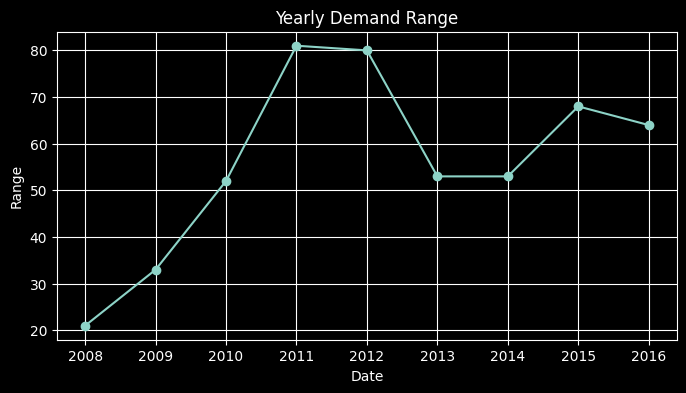

In [40]:
#EXPLORATORY ANALYSIS
yearly_range = df.groupby(df["Date"].dt.year)["Demand"].agg(
    Minimum="min",
    Maximum="max"
)

yearly_range["Range"] = yearly_range["Maximum"] - yearly_range["Minimum"]
print(yearly_range)

yearly_range["Range"].plot(marker="o", figsize=(8,4))
plt.title("Yearly Demand Range")
plt.ylabel("Range")
plt.grid(True)
plt.show()

In [41]:
#COMPARING ALL MODELS' ACCURACY
comparison = pd.DataFrame({
    "Model": ["SES", "Holt", "HW (Additive)", "HW (Multiplicative)", "HW(Add T + Mul S)"],
    "MAE": [
        12.953132505018432,
        13.299652487562868,
        10.339660028758507,
        9.98324351692399,
        10.017709826796052
    ],
    "MAPE": [
        9.662263975690491,
        9.975956185975914,
        8.115369213258756,
        7.825761959319018,
        7.825761959319018
    ]
})

comparison

,Model,MAE,MAPE
0,SES,12.953133,9.662264
1,Holt,13.299652,9.975956
2,HW (Additive),10.339660,8.115369
3,HW (Multiplicative),9.983244,7.825762
4,HW(Add T + Mul S),10.017710,7.825762
